**Understanding the Logistic Regression with Titanic Dataset and using  Classification Metrics to predict how any people has survived and died in that incident**

In [2]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as pt
import seaborn as sb

In [4]:
%matplotlib inline

In [5]:
df = sb.load_dataset('titanic') #Dataset to train the Model

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


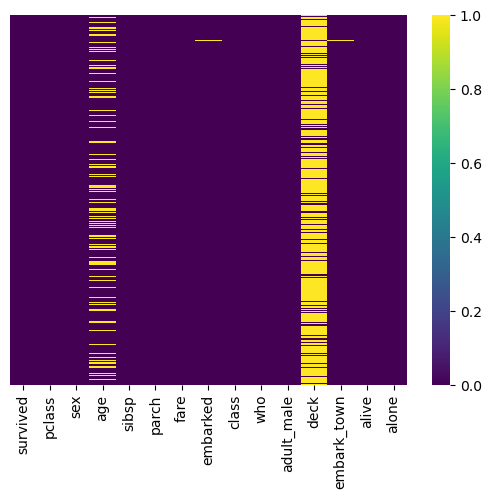

In [7]:
sb.heatmap(df.isnull(), yticklabels=False, cmap='viridis') #There are lots of data in age , deck, fare, embarked_rtoen where there is  null dataset we need to clean them for model to predict
pt.show()

In [8]:
df.isnull().value_counts()

survived  pclass  sex    age    sibsp  parch  fare   embarked  class  who    adult_male  deck   embark_town  alive  alone
False     False   False  False  False  False  False  False     False  False  False       True   False        False  False    530
                                                                                         False  False        False  False    182
                         True   False  False  False  False     False  False  False       True   False        False  False    158
                                                                                         False  False        False  False     19
                         False  False  False  False  True      False  False  False       False  True         False  False      2
Name: count, dtype: int64

In [9]:
df = df.drop('deck', axis=1)

In [10]:
df = df.drop('class', axis=1)

In [11]:
df = df.drop('embark_town', axis=1)

In [12]:
df = df.drop('alive', axis=1)

In [13]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,True


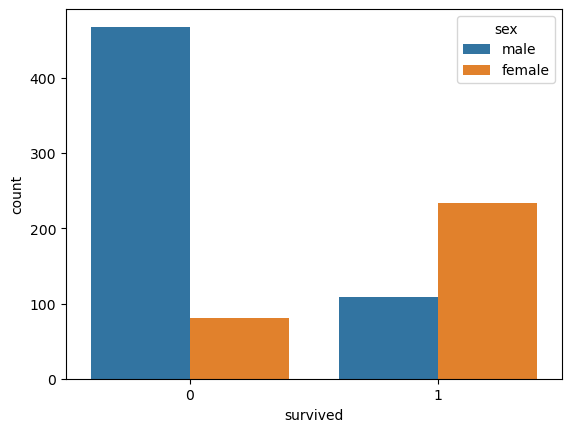

In [14]:
sb.countplot(x='survived', data=df, hue='sex') #From this we conclude that more number of male has dies 
pt.show()

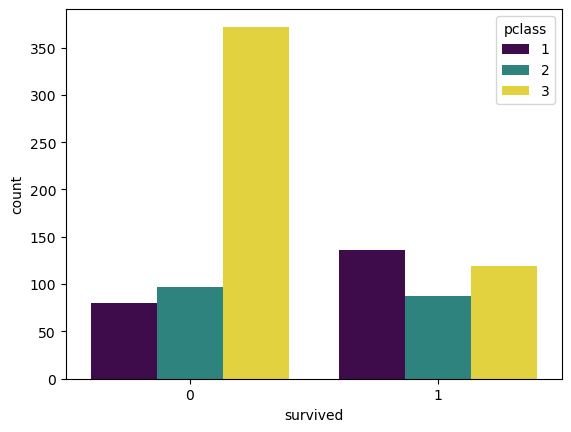

In [15]:
sb.countplot(x='survived', data=df, hue='pclass', palette='viridis') #From this we conclude that more number of people has died in P3 lower class
pt.show()

In [16]:
df.value_counts()

survived  pclass  sex   age   sibsp  parch  fare      embarked  who  adult_male  alone
0         3       male  17.0  0      0      8.6625    S         man  True        True     3
                        19.0  0      0      7.8958    S         man  True        True     3
          2       male  30.0  0      0      13.0000   S         man  True        True     3
                        23.0  0      0      13.0000   S         man  True        True     3
                        25.0  0      0      13.0000   S         man  True        True     3
                                                                                         ..
1         3       male  32.0  0      0      8.0500    S         man  True        True     1
0         1       male  24.0  0      1      247.5208  C         man  True        False    1
1         3       male  39.0  0      0      7.9250    S         man  True        True     1
                        44.0  0      0      7.9250    S         man  True        True

**Its Time to do predict and test the model**

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'who', 'adult_male', 'alone'],
      dtype='object')

In [19]:
df['age'] = df['age'].fillna(np.mean(df['age']))

In [20]:
X = df[['pclass', 'age', 'sibsp', 'fare']] #our feature dataset
y=df['survived'] #our target to know whether passenger has survived or not

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
lm = LogisticRegression()

In [24]:
lm.fit(X_train, y_train)

LogisticRegression()

In [25]:
pred = lm.predict(X_test)

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

In [27]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.71      0.89      0.79       175
           1       0.74      0.46      0.57       120

    accuracy                           0.72       295
   macro avg       0.72      0.67      0.68       295
weighted avg       0.72      0.72      0.70       295



In [28]:
print(confusion_matrix(y_test, pred))

[[156  19]
 [ 65  55]]


**Output**

**79 % of the predictions are for the people survived but 57 %% for people who dies , but still it depends on the various factors **